In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("trade_1988_2021.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634509 entries, 0 to 634508
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ReporterISO3            634509 non-null  object 
 1   ReporterName            634509 non-null  object 
 2   PartnerISO3             634509 non-null  object 
 3   PartnerName             634509 non-null  object 
 4   Year                    634509 non-null  int64  
 5   TradeFlowName           634509 non-null  object 
 6   TradeValue in 1000 USD  634441 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 33.9+ MB


,Year,TradeValue in 1000 USD
count,634509.000000,6.344410e+05
mean,2006.832168,1.180474e+06
std,8.708755,2.157618e+07
min,1988.000000,0.000000e+00
25%,2000.000000,1.570000e+02
50%,2007.000000,3.179969e+03
75%,2014.000000,5.025227e+04
max,2021.000000,2.590601e+09


In [3]:
df.shape

(634509, 7)

In [4]:
df.isnull().sum()

ReporterISO3               0
ReporterName               0
PartnerISO3                0
PartnerName                0
Year                       0
TradeFlowName              0
TradeValue in 1000 USD    68
dtype: int64

In [5]:
# Фильтрация только импорта
imports = df[df["TradeFlowName"].str.lower().str.contains("Export")]

imports.shape

(0, 7)

In [6]:
df["TradeFlowName"].value_counts()

TradeFlowName
Export    634509
Name: count, dtype: int64

In [8]:
country_imports = (
    df.groupby("PartnerName")["TradeValue in 1000 USD"]
    .sum()
    .sort_values(ascending=False)
)

country_imports.head(10)

PartnerName
 World              3.744698e+11
United States       5.292351e+10
China               2.383121e+10
Germany             2.351166e+10
United Kingdom      1.484969e+10
France              1.440785e+10
Japan               1.401826e+10
Netherlands         1.196451e+10
Hong Kong, China    1.185559e+10
Italy               1.047452e+10
Name: TradeValue in 1000 USD, dtype: float64

После группировки данных по странам-партнёрам видно, что импорт распределён неравномерно. Большая часть мирового импорта приходится на небольшое количество стран, а остальные импортируют значительно меньше.
Это означает, что мировая торговля сильно зависит от крупнейших экономик: именно они формируют основной спрос на товары.

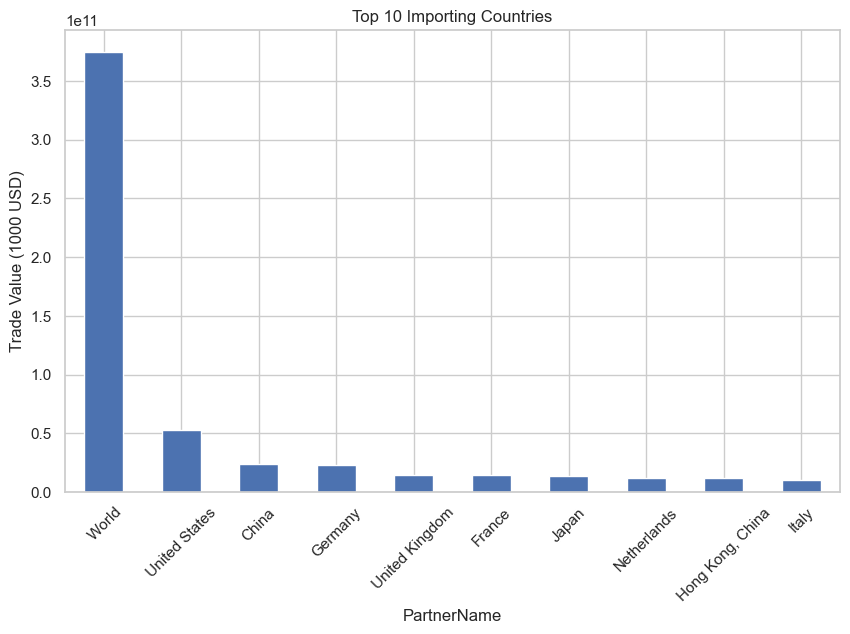

In [9]:
top10 = country_imports.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind="bar")
plt.title("Top 10 Importing Countries")
plt.ylabel("Trade Value (1000 USD)")
plt.xticks(rotation=45)
plt.show()

В топ-10 входят самые развитые и крупные страны. Они импортируют больше остальных, потому что у них большое население, развитая промышленность и высокий уровень потребления.
Многие товары и сырьё выгоднее закупать за рубежом, поэтому такие страны активно участвуют в международной торговле и формируют её основной объём.

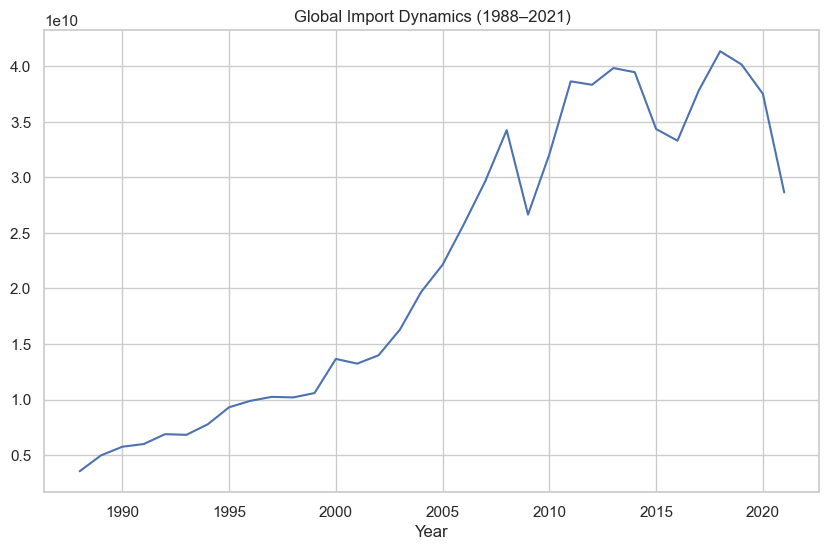

In [10]:
yearly_imports = (
    df.groupby("Year")["TradeValue in 1000 USD"]
    .sum()
)

plt.figure(figsize=(10,6))
yearly_imports.plot()
plt.title("Global Import Dynamics (1988–2021)")
plt.show()

По графику видно, что мировой импорт в целом растёт со временем. Это связано с развитием глобальной экономики и увеличением торговли между странами.
Иногда наблюдаются небольшие спады — скорее всего это периоды экономических кризисов. После них объёмы снова увеличиваются, поэтому общий тренд остаётся положительным.